In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import cv2
import random


In [7]:
DS = Path("../../datasets")
SAMPLES = DS / "samples_mapillary"
DATA_DIR = SAMPLES / "chandni_chowk/images"
NUM_SAMPLES = 20

In [14]:
from fastai.vision.all import load_learner

EXPORT_PKL = '/Users/hariomnarang/Desktop/gdrive-sync/garbage/experiments/T007-engulf-only-uncentered/log/export_iter_4.pkl'
SIZE = 50
learn = load_learner(EXPORT_PKL)


/Users/hariomnarang/Desktop/personal/roads/mtrain/.venv/lib/python3.12/site-packages/fastai/learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")


In [6]:
from mtrain.smallnet.unet.predict import predict_unet, predict_unet_only_mask

In [11]:
import random
images = list(DATA_DIR.glob("*.jpg"))
random.shuffle(images)
images = images[:NUM_SAMPLES]

In [15]:
res = [
    predict_unet(img, SIZE, learn)
    for img in images
]

100%|██████████| 336/336 [00:00<00:00, 20111.11it/s]


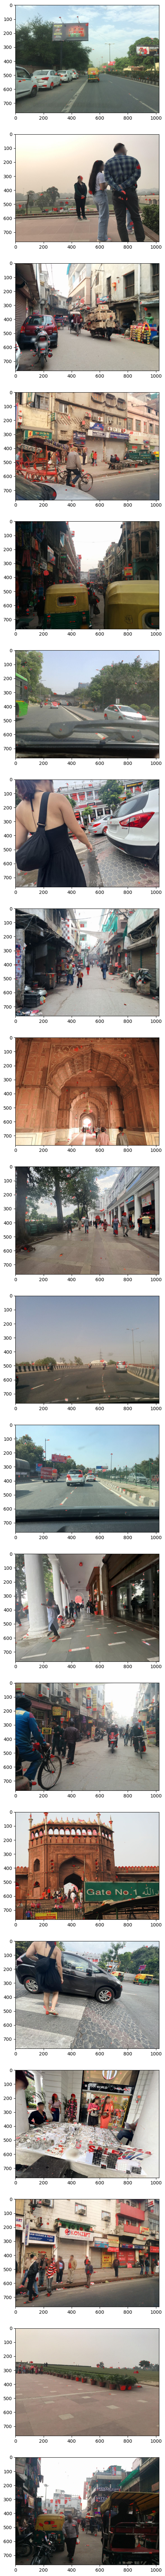

In [19]:
_, ax = plt.subplots(len(res), 1, figsize=(100,100))
for i, r in enumerate(res):
    ax[i].imshow(r)
plt.show()